# CROP: Central Roundish Object Painter — minimal inference demo

**Paper:** Motohisa Fukuda, Takashi Okuno, Hideki Murayama, *Central object segmentation by deep learning for fruits and other roundish objects*, [arXiv:2008.01251v2](https://arxiv.org/abs/2008.01251v2) (journal version: [Sensors 2021, 21(21), 6999](https://doi.org/10.3390/s21216999)).
**Author code:** [github.com/MotohisaFukuda/CROP](https://github.com/MotohisaFukuda/CROP) @ commit `8f48aa5081f103f30e48bcfe1d6aba242f691273` (Apache-2.0).

**Purpose.** CROP is a deeper U-Net that identifies and paints the *central roundish object* of an RGB image and reports the object's pixel size (median of eleven measurement scales) and its center of mass. This notebook reproduces the authors' own minimal demo flow (`demo.ipynb` + `source.py` + the default dictionary `net_dic_0314_05000` from release v1.0) on one fixed sample image, as documented in `demo_internet_images/README.md`.

**Scope (partial demonstration).** Pretrained inference on **one** image only. No training, fine-tuning, dataset benchmarks, or the 510-photo time-series pipeline. Measurements are in **pixels**; the paper describes no pixel→physical calibration.

**Sample.** `images/338_i.png` from the author repository — the input the authors themselves show for the measurement demo (README: "The first figure was the input"). The sample URL is pinned to the exact commit.

**実行ランタイム:** 推奨は **GPU (T4)** です。CPU でも動作しますが、D4 平均を含む 96 回の 512×512 推論のため数倍遅くなります。**ランタイム → ランタイムの種類を変更** から選択してください。

**実行方法:** すべてのセルを上から順に実行（ランタイム → すべてのセルを実行）。ダウンロード合計は約 570 MiB（重み zip）+ 数十 KiB（コード・画像）です。

**AI 使用に関する注記:** このノートブックは著者の `demo.ipynb` の流れに沿って**AI が組み立て**ました。科学計算自体はすべて pinned commit の著者コード `source.py` をそのままダウンロードして実行します（翻訳や再実装はしていません）。`input()` による URL 入力を固定サンプル URL に置き換えた点が主な変更です。


## 1. Runtime check

We verify PyTorch/torchvision availability and detect the allocated device exactly as the authors' first demo cell does (`"cuda:0" if torch.cuda.is_available() else "cpu"`). No extra packages are installed: the author code needs only torch, torchvision, numpy, Pillow, matplotlib and IPython, all preinstalled on Colab. The device is reported from the actual runtime — nothing is assumed.

**Expected result:** printed torch/torchvision versions and either `cuda:0` with a T4 GPU name, or `cpu` on a CPU runtime.

**期待される結果:** torch/torchvision のバージョンと、T4 GPU なら `cuda:0`、CPU ランタイムなら `cpu` が表示されます。

In [ ]:
import torch, torchvision, time
print("torch", torch.__version__, "| torchvision", torchvision.__version__)
device = "cuda:0" if torch.cuda.is_available() else "cpu"
if device == "cuda:0":
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("CPU runtime: inference will run, but expect several minutes for the D4-averaged measurement.")
assert device in ("cuda:0", "cpu")


torch 2.11.0+cu130 | torchvision 0.26.0+cu130
GPU: Tesla T4


## 2. Fetch the pinned author code (`source.py`)

We download `source.py` — the single file that defines the CROP network (`UNetConvDeep7`), the D4-averaged segmenter (`SegmentingImage`/`ProcessingImage`), and the eleven-scale median measurement (`AnalyzingImage.adjust_automatically`) — from the pinned commit `8f48aa5081f103f30e48bcfe1d6aba242f691273` and record its SHA-256 so the executed code is exactly the author code at that revision.

**Expected result:** the file is saved under `/content` and its SHA-256 and byte size are printed.

**期待される結果:** `source.py` が `/content` に保存され、SHA-256 とサイズが表示されます。

In [ ]:
import hashlib, urllib.request, os
SOURCE_URL = "https://raw.githubusercontent.com/MotohisaFukuda/CROP/8f48aa5081f103f30e48bcfe1d6aba242f691273/source.py"
urllib.request.urlretrieve(SOURCE_URL, "/content/source.py")
src = open("/content/source.py", "rb").read()
print("source.py:", len(src), "bytes | sha256:", hashlib.sha256(src).hexdigest())
assert len(src) > 10000


source.py: 19313 bytes | sha256: 7e617db0f2b134b3b67c1f10aa70e115088fa96f0689215d63d4e5f2c939c32c


## 3. Download the pretrained CROP dictionary (release v1.0)

The weights are the release asset `net_dic_0314_05000.zip` — the default fruit-trained dictionary named in the authors' demo README. We verify the exact published byte size (597,325,716 bytes, GitHub release metadata) before extraction and let `zipfile` validate CRCs on extraction. This is a ~570 MiB download; it runs once into the VM-local `/content` directory.

**Expected result:** the archive is downloaded with the expected size, extracted, and the inner dictionary file name is printed.

**期待される結果:** 公表サイズと一致する zip がダウンロード・展開され、辞書ファイル名が表示されます（数分かかります）。

In [ ]:
import zipfile
WEIGHT_URL = "https://github.com/MotohisaFukuda/CROP/releases/download/v1.0/net_dic_0314_05000.zip"
WEIGHT_EXPECTED_BYTES = 597325716
zip_path = "/content/net_dic_0314_05000.zip"
t0 = time.time()
urllib.request.urlretrieve(WEIGHT_URL, zip_path)
n_bytes = os.path.getsize(zip_path)
print(f"downloaded {n_bytes:,} bytes in {time.time()-t0:.1f} s")
assert n_bytes == WEIGHT_EXPECTED_BYTES, "weight archive size mismatch"
with zipfile.ZipFile(zip_path) as zf:
    bad = zf.testzip()
    assert bad is None, f"CRC failure: {bad}"
    zf.extractall("/content/crop_weights")
    print("archive members:", zf.namelist())
DIC_PATH = "/content/crop_weights/net_dic_0314_05000"
assert os.path.exists(DIC_PATH), "expected dictionary file net_dic_0314_05000"


downloaded 597,325,716 bytes in 75.0 s


archive members: ['net_dic_0314_05000']


## 4. Download the sample image

The sample is `images/338_i.png` at the pinned commit — the input of the authors' own measurement demonstration (a pear; the paper's Section-2-style measurement figure uses this input). We check the PNG signature and record its SHA-256.

**Expected result:** a valid PNG is saved and its dimensions are printed.

**期待される結果:** 有効な PNG が保存され、画像サイズが表示されます。

In [ ]:
import hashlib
IMG_URL = "https://raw.githubusercontent.com/MotohisaFukuda/CROP/8f48aa5081f103f30e48bcfe1d6aba242f691273/images/338_i.png"
urllib.request.urlretrieve(IMG_URL, "/content/338_i.png")
img_bytes = open("/content/338_i.png", "rb").read()
assert img_bytes[:8] == b"\x89PNG\r\n\x1a\n", "not a PNG file"
print("338_i.png:", len(img_bytes), "bytes | sha256:", hashlib.sha256(img_bytes).hexdigest())


338_i.png: 30504 bytes | sha256: 3cdcb9ff427fc59bcd257e3c325146db81a29b106e3620959293fb24ab97eb96


## 5. Input preview

Before any inference we display the actual sample image, so the reader sees exactly what CROP is applied to. This is the raw input only — no annotations exist for this image in the repository.

**Expected result:** the pear photograph is displayed.

**期待される結果:** サンプル画像（梨の写真）が表示されます。

sample image size (W×H): (115, 115)


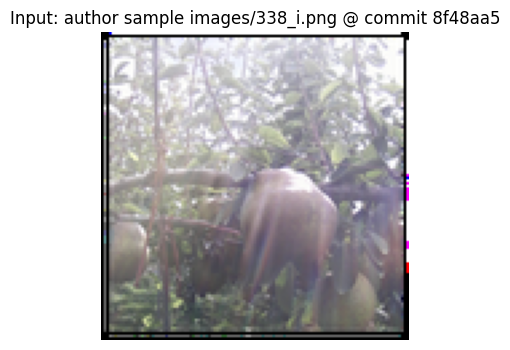

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
pic_original = Image.open("/content/338_i.png").convert("RGB")
print("sample image size (W×H):", pic_original.size)
plt.figure(figsize=(4, 4))
plt.imshow(pic_original)
plt.axis("off")
plt.title("Input: author sample images/338_i.png @ commit 8f48aa5")
plt.show()


## 6. Load CROP with the pretrained dictionary

This mirrors the authors' first demo cell: `from source import *`, device auto-detection, and `AnalyzingImage(dic_name="net_dic_0314_05000", ...)` with the demo defaults — `threshold=0.5`, `average=True` (the paper's D4 eight-symmetry averaging, §4.4), `mode="median"` (eleven scales 1.0–2.0, median of pixel counts, §2/§3), and all visual outputs enabled. The only changes from the authors' cell: the dictionary path points at our extracted file and `show_adjust_process=True` (as in their committed `demo.ipynb`). The paper reports 160,829,681 parameters (§4.5), which we verify against the loaded network. If the checkpoint needs the legacy unpickling path (torch ≥ 2.6 `weights_only` default), a labeled fallback reloads it with `weights_only=False` — the bytes are still the author-pinned archive.

**Expected result:** the network loads on the detected device and the printed parameter count equals 160,829,681.

**期待される結果:** ネットワークが読み込まれ、パラメータ数が論文 §4.5 の 160,829,681 と一致します。

In [ ]:
import sys
sys.path.insert(0, "/content")
from source import AnalyzingImage, UNetConvDeep7
try:
    segment_image = AnalyzingImage(dic_name=DIC_PATH, device=device, threshold=0.5, average=True,
                                   mode="median", save_all=False, show_adjusted=False,
                                   show_adjust_process=True, show_final=True, show_in_original=True,
                                   size_pointer1=5, size_pointer2=10)
except Exception as e:
    print(f"initial load failed ({type(e).__name__}); retrying with weights_only=False (author-pinned bytes only)")
    import torch, functools
    _orig_load = torch.load
    torch.load = functools.partial(_orig_load, weights_only=False)
    try:
        segment_image = AnalyzingImage(dic_name=DIC_PATH, device=device, threshold=0.5, average=True,
                                       mode="median", save_all=False, show_adjusted=False,
                                       show_adjust_process=True, show_final=True, show_in_original=True,
                                       size_pointer1=5, size_pointer2=10)
    finally:
        torch.load = _orig_load
network = segment_image.segment_image.segment.network
n_params = sum(p.numel() for p in network.parameters())
print("loaded CROP parameters:", f"{n_params:,}")
assert n_params == 160_829_681, "parameter count does not match paper Section 4.5"


loaded CROP parameters: 160,829,681


## 7. Run the measurement pipeline (eleven scales, median)

Following the authors' final demo tab `segment_image(pic_original, center, scale)`: the code first segments a 512×512 resized crop to adjust the framing around the central object, then crops at eleven rates r = 1.0…2.0 (step 0.1), runs the D4-averaged segmentation at each scale, re-scales pixel counts back to the original image scale, and picks the median result. With `show_adjust_process=True` this prints the eleven masked crops; `show_final=True` prints the median result and the histogram of the eleven measurements; `show_in_original=True` draws the center of mass back onto the original photo. On CPU this cell takes several minutes; on T4 well under a minute.

**Expected result:** eleven rate/mask images, the central (median) estimate with its rate and pixel count, a histogram of the eleven measurements, and the center-of-mass marker on the original image.

**期待される結果:** 11 段階のマスク画像、中央値（rate・ピクセル数）の表示、11 測定値のヒストグラム、元画像上の重心マーカー。

center=(57, 57), scale=57 on 115x115 input

rate: 1.0 pixcels: 441.4100646972656


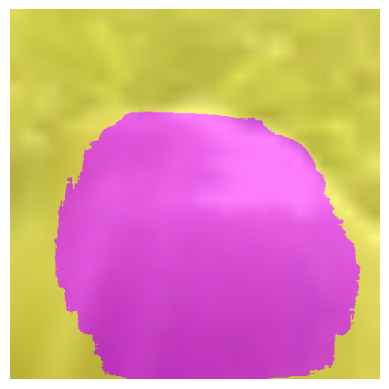

rate: 1.1 pixcels: 519.5166091918945


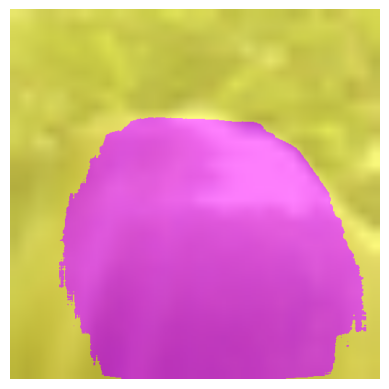

rate: 1.2 pixcels: 576.1312866210938


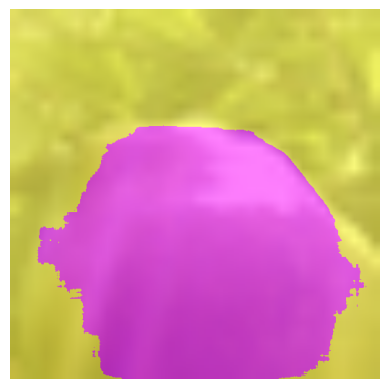

rate: 1.3 pixcels: 690.3577537536621


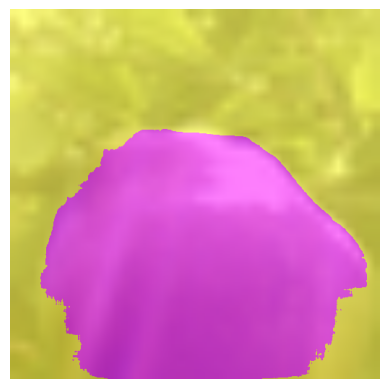

rate: 1.4 pixcels: 808.2151336669922


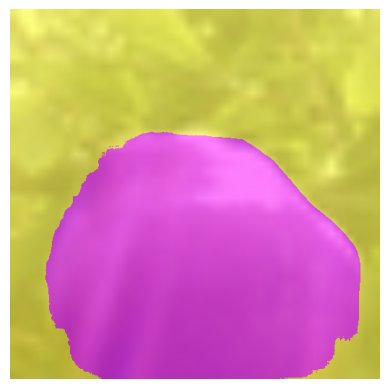

rate: 1.5 pixcels: 891.3911819458008


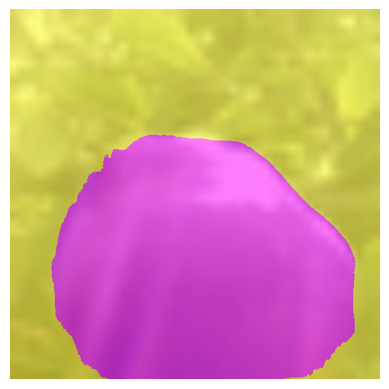

rate: 1.6 pixcels: 921.498046875


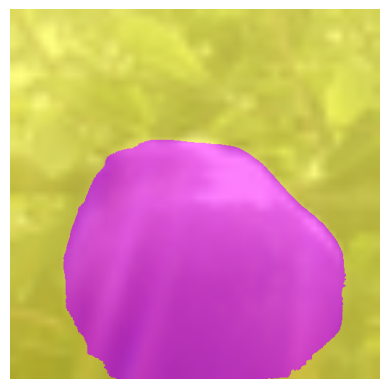

rate: 1.7 pixcels: 932.1844139099121


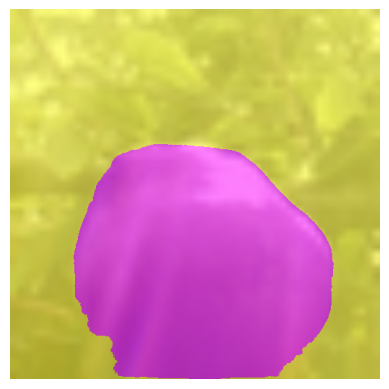

rate: 1.8 pixcels: 990.0611114501953


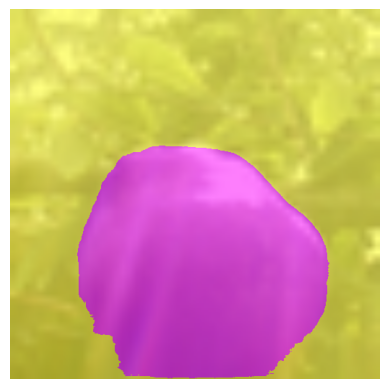

rate: 1.9 pixcels: 1069.8830680847168


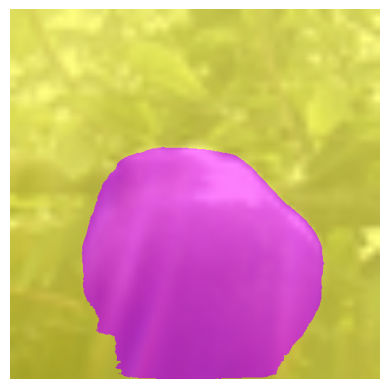

rate: 2.0 pixcels: 1079.5852661132812


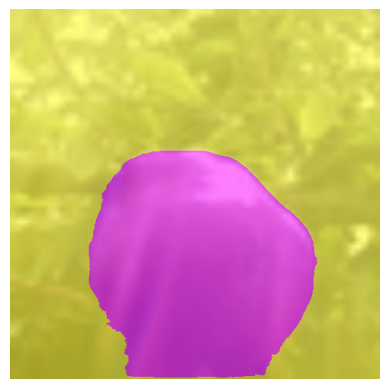

central estimate
rate 1.4
number of pixels 808.2151336669922


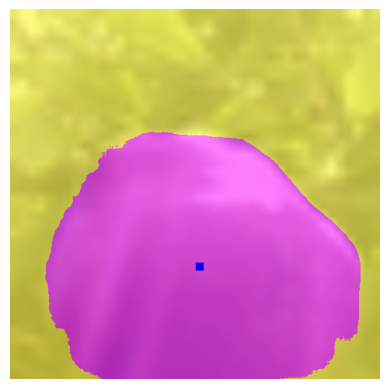

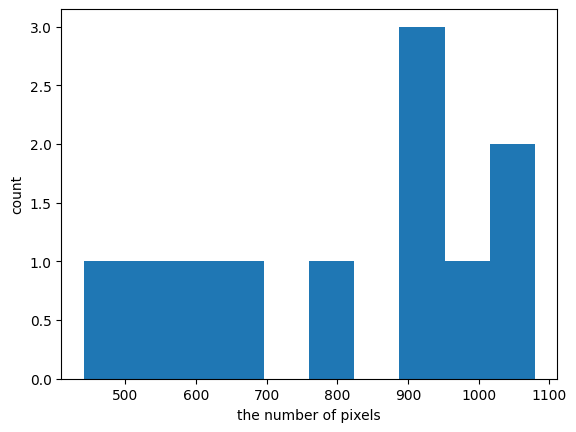

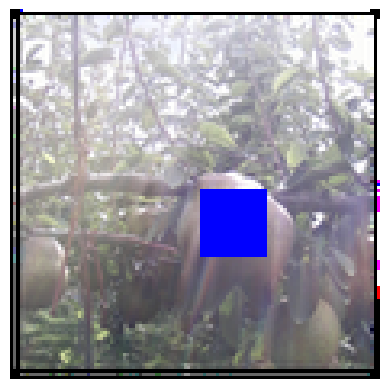

inference wall time: 7.0 s
central estimate: rate=1.4, pixels=808.2151336669922 (re-scaled to original image)
center of mass in original image: x=69.5, y=66.2 (0-based, x right, y down)


In [ ]:
# The authors' crop uses a square frame of half-width `scale` centered at `center`;
# for the 512×512 sample the full frame (center=(256,256), scale=256) is exact.
w, h = pic_original.size
center = (w // 2, h // 2)
scale = min(w, h) // 2
print(f"center={center}, scale={scale} on {w}x{h} input")
t0 = time.time()
(pic_selected, pixels_median, cm_back, rate_median, cs_adjusted, data_all) = segment_image(pic_original, center, scale)
elapsed = time.time() - t0
print(f"inference wall time: {elapsed:.1f} s")
cm_x, cm_y = float(cm_back[0]), float(cm_back[1])
print(f"central estimate: rate={rate_median}, pixels={pixels_median} (re-scaled to original image)")
print(f"center of mass in original image: x={cm_x:.1f}, y={cm_y:.1f} (0-based, x right, y down)")


## 8. Measurement table and CSV export

We tabulate the eleven scale-dependent pixel counts returned by the author pipeline (`data_all[0]`) and mark the row the pipeline itself selected as its central estimate (the `result_sorted[4]` step inside `AnalyzingImage.adjust_automatically`, source.py L334) — the selection shown in the previous cell, not a recomputation. The spread across scales is exactly what the authors' central-selection step is designed to suppress; the histogram in the previous cell shows the same values. This table is generated by this notebook from the actual run — it is not an author figure.

**Expected result:** an 11-row table (scale rate, pixel count, author-selected flag) and a saved CSV file.

**期待される結果:** 11 行の測定表（スケール率・ピクセル数・著者パイプライン選択フラグ）と CSV 保存。

In [ ]:
import pandas as pd
df = pd.DataFrame({"rate": segment_image.rates, "pixels": data_all[0]})
df["author_selected"] = df["rate"] == rate_median
display(df)
df.to_csv("/content/crop_measurements.csv", index=False)
print("saved /content/crop_measurements.csv")


,rate,pixels,author_selected
0,1.0,441.410065,False
1,1.1,519.516609,False
2,1.2,576.131287,False
3,1.3,690.357754,False
4,1.4,808.215134,True
5,1.5,891.391182,False
6,1.6,921.498047,False
7,1.7,932.184414,False
8,1.8,990.061111,False
9,1.9,1069.883068,False


saved /content/crop_measurements.csv


## 9. Interpretation, validation record, references

**What was executed.** The authors' exact inference pipeline (`source.py` @ `8f48aa5`, release-v1.0 dictionary `net_dic_0314_05000`) ran on the authors' own sample input `images/338_i.png`, with demo defaults (D4 averaging, threshold 0.5, median of 11 scales). The printed pixel count is in units of the original image; the paper reports no physical calibration, so no mm size can be derived.

**What this does and does not verify.** A single-image run demonstrates that the released pipeline executes and behaves plausibly (a mask covering the central fruit, a coherent measurement histogram). It does **not** verify the paper's dataset-level accuracy (validation IoU 0.985 on Data_Fruits, Table 1 results) — that would require the unreleased annotated datasets. This run is a partial demonstration.

**Differences from the authors' flow.** (1) The `input()` URL prompt is replaced by a fixed pinned sample; (2) the dictionary path points to the extracted release asset; (3) a parameter-count check and explicit size/SHA-256 assertions were added. The scientific operations are the untouched author code.

**References.** Paper: arXiv:2008.01251v2 (§2.3 generality, §4.3.1 training, §4.4 D4 averaging, §4.5 depth/parameter counts). Code: `source.py` (`UNetConvDeep7` L59, `SegmentingImage` L207, `AnalyzingImage.adjust_automatically` L298) and `demo.ipynb`/`demo_internet_images/README.md` @ commit `8f48aa5`. License: Apache-2.0.

**このノートブックについて:** 著者コードをそのまま実行した 1 例の部分的再現です。論文のデータセット全体の精度検証は含みません。測定値はピクセル単位です。